## 0. テキスト処理のツール
### 0.1 形態素解析
#### 意味を持つ最小単位のことを形態素と呼ぶ。
#### 文を形態素ごとに分割し、品詞情報などを付け加える作業を形態素解析、機械的に形態素解析を行うシステムを形態素解析器と呼ぶ。

## MeCab
#### MeCabは 京都大学情報学研究科−日本電信電話株式会社コミュニケーション科学基礎研究所 共同研究ユニットプロジェクトを通じて開発されたオープンソース 形態素解析エンジンである。 言語, 辞書,コーパスに依存しない汎用的な設計を 基本方針としている。
#### ほとんどのOSに対応するバージョンが公開され、日本で最も広く使用されている。

In [1]:
# python環境上のMecabをインストールする。
!pip install mecab-python3
!pip install unidic

  Using cached unidic-1.1.0-py3-none-any.whl
  Using cached wasabi-0.10.1-py3-none-any.whl.metadata (28 kB)
  Using cached plac-1.4.5-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached plac-1.4.5-py2.py3-none-any.whl (22 kB)
Using cached wasabi-0.10.1-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/3 [wasabi]
   -------------------------- ------------- 2/3 [unidic]
   ---------------------------------------- 3/3 [unidic]



In [2]:
import MeCab
import unidic

In [3]:
tagger = MeCab.Tagger()  # 「tagger = MeCab.Tagger('-d ' + unidic.DICDIR)」
sample_txt = '草間リチャード敬太'
result = tagger.parse(sample_txt)
print(result)

RuntimeError: 
----------------------------------------------------------

Failed initializing MeCab. Please see the README for possible solutions:

    https://github.com/SamuraiT/mecab-python3#common-issues

If you are still having trouble, please file an issue here, and include the
ERROR DETAILS below:

    https://github.com/SamuraiT/mecab-python3/issues

issueを英語で書く必要はありません。

------------------- ERROR DETAILS ------------------------
arguments: 
default dictionary path: C:\Users\mzjin\AppData\Local\Programs\Python\Python311\Lib\site-packages\unidic\dicdir
[ifs] no such file or directory: C:\Users\mzjin\AppData\Local\Programs\Python\Python311\Lib\site-packages\unidic\dicdir\mecabrc
----------------------------------------------------------


## -Oオプション：出力フォーマットを指定します。

-Ochasen：茶筅（chasen）形式。形態素、読み、基本形、品詞などの情報がタブ区切りで出力されます。
-Owakati：分かち書き形式。形態素のみをスペース区切りで出力します。
-Oyomi：読み形式。形態素の読みのみを出力します。
-Okanji：漢字形式。形態素の漢字のみを出力します（形態素が漢字でない場合はそのまま）。
-dオプション：使用する辞書のディレクトリを指定します。

## -d <directory>：指定したディレクトリにある辞書を使用します。
-uオプション：ユーザー辞書を指定します。

-u <file>：指定したユーザー辞書を使用します。
-rオプション：設定ファイルを指定します。

-r <file>：指定した設定ファイルを使用します。
-lオプション：解析の深さを指定します。

-l <number>：指定した深さまで解析します。
-pオプション：出力プロセスの進行状況を表示します。

-p：進行状況を表示します。
-aオプション：全ての形態素候補を出力します。

-a：全ての形態素候補を出力します。
-Nオプション：Nベストの結果を出力します。

-N <number>：指定した数の最良の解析結果を出力します。

In [5]:
# 例1：茶筅（chasen）形式で解析
text="私は昨日、友達と渋谷でランチをしました。"

# Nベスト結果を出力
tagger = MeCab.Tagger()
#tagger = MeCab.Tagger("-N 0")
result = tagger.parse(text)
print(result)

RuntimeError: 
----------------------------------------------------------

Failed initializing MeCab. Please see the README for possible solutions:

    https://github.com/SamuraiT/mecab-python3#common-issues

If you are still having trouble, please file an issue here, and include the
ERROR DETAILS below:

    https://github.com/SamuraiT/mecab-python3/issues

issueを英語で書く必要はありません。

------------------- ERROR DETAILS ------------------------
arguments: 
default dictionary path: C:\Users\mzjin\miniconda3\Lib\site-packages\unidic\dicdir
[ifs] no such file or directory: C:\Users\mzjin\miniconda3\Lib\site-packages\unidic\dicdir\mecabrc
----------------------------------------------------------


In [7]:
## 集計のためのライブラリpandasを読み込みます。
# !pip install pandas

In [12]:
import pandas as pd
from collections import Counter
parsed_text= tagger.parse(text)

# 形態素解析の結果をリストに格納
words = []
for line in parsed_text.splitlines():
    if line == "EOS":
        break
    word_info = line.split('\t')
    if len(word_info) > 1:
        words.append(word_info[0])

# word_info[0]は単語、1はタグの情報
# 単語の頻度をカウント
word_counts = Counter(words)

# データフレームに変換
df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count'])
df = df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# 結果を表示
print(df)


   Word  Count
0     私      1
1     は      1
2    昨日      1
3     、      1
4    友達      1
5     と      1
6    渋谷      1
7     で      1
8   ランチ      1
9     を      1
10    し      1
11   まし      1
12    た      1
13    。      1


In [11]:
# 品詞を指定して集計する
from collections import defaultdict

def aggregate_words(text, pos_tags):
    tagger = MeCab.Tagger()
    tagger.parse("")  # Initialize the tagger

    word_counts = defaultdict(int)
    
    node = tagger.parseToNode(text)
    while node:
        if node.feature.split(',')[0] in pos_tags:
            word_counts[node.surface] += 1
        node = node.next
    
    return word_counts

# Example usage
pos_tags = ["名詞", "形容詞"]  # Specify the POS tags you want to aggregate
pos_tags1 = ["代名詞"]
results = aggregate_words(text, pos_tags)
for word, count in results.items():
    print(f"{word}\t {count}")


昨日	 1
友達	 1
渋谷	 1
ランチ	 1


In [13]:
# MeCabを使った形態素解析
mecab = MeCab.Tagger()
parsed_text = mecab.parse(text)

# 形態素解析の結果をリストに格納
level2_tags = []
for line in parsed_text.splitlines():
    if line == "EOS":
        break
    word_info = line.split('\t')
    if len(word_info) > 1:
        # 品詞情報を「,」で分割し、レベル2の情報を取得
        pos_info = word_info[1].split(',')
        if len(pos_info) > 1:
            level2_tags.append(pos_info[1])

# レベル2の品詞タグの頻度をカウント
tag_counts = Counter(level2_tags)

# 結果を表示
for tag, count in tag_counts.items():
    print(f"{tag}: {count}")

: 3
係助詞: 1
普通名詞: 3
読点: 1
格助詞: 3
固有名詞: 1
非自立可能: 1
句点: 1


In [18]:
import MeCab
from collections import Counter

# 日本語テキスト

# 指定するレベル2品詞タグ
target_level2_tag = "固有名詞"

# MeCabを使った形態素解析
mecab = MeCab.Tagger()
parsed_text = mecab.parse(text)

# 指定されたレベル2の品詞タグに属する単語を集計
words_with_target_tag = []

for line in parsed_text.splitlines():
    if line == "EOS":
        break
    word_info = line.split('\t')
    if len(word_info) > 1:
        # 品詞情報を「,」で分割し、レベル2の情報を取得
        pos_info = word_info[1].split(',')
        if len(pos_info) > 1 and pos_info[1] == target_level2_tag:
            word = word_info[0]
            words_with_target_tag.append(word)

# 指定されたレベル2品詞タグに属する単語の頻度をカウント
word_counts = Counter(words_with_target_tag)

# 結果を表示
print(f"レベル2品詞タグ: {target_level2_tag} に属する単語の出現頻度")
for word, count in word_counts.items():
    print(f"{word}: {count}")

レベル2品詞タグ: 固有名詞 に属する単語の出現頻度
ドイツ: 1
ハンブルク: 2
日本: 1


In [14]:
# 指定するレベル2品詞タグのリスト
target_level2_tags = ["固有名詞", "一般", "読点"]

# MeCabを使った形態素解析
mecab = MeCab.Tagger()
parsed_text = mecab.parse(text)

# 指定されたレベル2の品詞タグに属する単語を集計
words_with_target_tags = defaultdict(list)

for line in parsed_text.splitlines():
    if line == "EOS":
        break
    word_info = line.split('\t')
    if len(word_info) > 1:
        # 品詞情報を「,」で分割し、レベル2の情報を取得
        pos_info = word_info[1].split(',')
        if len(pos_info) > 1 and pos_info[1] in target_level2_tags:
            word = word_info[0]
            words_with_target_tags[pos_info[1]].append(word)

# 指定されたレベル2品詞タグに属する単語の頻度をカウント
word_counts = {tag: Counter(words) for tag, words in words_with_target_tags.items()}

# 結果を表示
for tag, counts in word_counts.items():
    for word, count in counts.items():
        print(f"{word}\t{count}")


、	1
渋谷	1


In [29]:
# テキストを読み込み
import requests

url = "https://raw.githubusercontent.com/mining-jin/data-/main/sakubun259/akke2.txt"
r = requests.get(url)
r.raise_for_status()

r.encoding = "cp932"   # ← Windows日本語環境のShift-JIS相当（まずこれ）
text = r.text

print(text[:200])


私にとって、これから生きていくうえで、無くてはならない物を５つ上げるとしたら、その中に、ちょっと寒いけど、友達が入ると思う。
友達って、やはり多い方がいいと思う。
その時期、その時期によって友達は変わるものだ。
例えば、高校の友達、大学の友達、バイトの友達等で、環境が変われば、自分を取り囲んでくれる人も変わるから、友達が変わるのは、あたり前だと思う。
そうすると、友達たくさんいるのかな？
、と思う


In [15]:
# テキストを読み込み
import requests

url = "https://raw.githubusercontent.com/mining-jin/data-/main/sakubun259/akke2.txt"
r = requests.get(url)
r.raise_for_status()
raw = r.content

for enc in ["cp932", "shift_jis", "utf-8"]:
    try:
        text = raw.decode(enc)
        break
    except UnicodeDecodeError:
        continue

print(text[:200])

私にとって、これから生きていくうえで、無くてはならない物を５つ上げるとしたら、その中に、ちょっと寒いけど、友達が入ると思う。
友達って、やはり多い方がいいと思う。
その時期、その時期によって友達は変わるものだ。
例えば、高校の友達、大学の友達、バイトの友達等で、環境が変われば、自分を取り囲んでくれる人も変わるから、友達が変わるのは、あたり前だと思う。
そうすると、友達たくさんいるのかな？
、と思う


In [35]:
import pandas as pd

df = pd.DataFrame(sorted(results.items(), key=lambda x: x[1], reverse=True),
                  columns=["word", "count"])
df.to_csv("pos_counts.csv", index=False, encoding="utf-8-sig")
print("saved: pos_counts.csv")


saved: pos_counts.csv


In [17]:
import requests
import MeCab
from collections import defaultdict

# ============================================================
# 設定
# ============================================================
url = "https://raw.githubusercontent.com/mining-jin/data-/main/sakubun259/akke2.txt"

# 解析したい品詞キーワード（UniDic/環境差を吸収するため feature 全体で判定）
pos_keywords = ["固有名詞", "普通名詞", "接尾", "非自立"]

# 画面に出す件数
TOP_N = 50

# ============================================================
# テキスト取得（文字化け対策：cp932/shift_jis 優先→utf-8）
# ============================================================
r = requests.get(url)
r.raise_for_status()
raw = r.content

text = None
used_enc = None
for enc in ["cp932", "shift_jis", "utf-8"]:
    try:
        text = raw.decode(enc)
        used_enc = enc
        break
    except UnicodeDecodeError:
        continue

if text is None:
    raise UnicodeDecodeError("Unable to decode the text with cp932/shift_jis/utf-8")

#print(f"[INFO] decoded encoding = {used_enc}")
#print("[INFO] preview (first 200 chars):")
#print(text[:200])
#print("-" * 60)

# ============================================================
# 品詞指定集計
# ============================================================
def aggregate_words(text, pos_keywords):
    tagger = MeCab.Tagger()
    tagger.parse("")  # Initialize (Windowsで安定)

    word_counts = defaultdict(int)
    total_tokens = 0
    matched_tokens = 0

    node = tagger.parseToNode(text)  # 全文一括解析
    while node:
        surf = node.surface
        feats = node.feature.split(",")

        # BOS/EOS と空トークンを除外
        if surf and feats and feats[0] != "BOS/EOS":
            total_tokens += 1

            # features のどこかに pos_keywords が含まれていればカウント
            if any(k in feats for k in pos_keywords):
                word_counts[surf] += 1
                matched_tokens += 1

        node = node.next

    return word_counts, total_tokens, matched_tokens

results, total_tokens, matched_tokens = aggregate_words(text, pos_keywords)

# ============================================================
# 画面上に一部分を出力（上位TOP_N）
# ============================================================
print(f"[INFO] total tokens   = {total_tokens}")
print(f"[INFO] matched tokens = {matched_tokens}")
print(f"[INFO] unique words (matched) = {len(results)}")
print("=" * 60)

if not results:
    print("[WARN] 集計結果が0件です。pos_keywords を辞書の品詞体系に合わせて調整してください。")
else:
    print(f"[RESULT] Top {TOP_N} words:")
    for word, count in sorted(results.items(), key=lambda x: x[1], reverse=True)[:TOP_N]:
        print(f"{word}\t{count}")


[INFO] total tokens   = 1019
[INFO] matched tokens = 181
[INFO] unique words (matched) = 87
[RESULT] Top 50 words:
友達	20
人	12
事	9
年	6
みんな	6
方	5
今	5
時	5
数	4
本当	4
中学	4
高校	3
大学	3
自分	3
刺激	3
田舎	3
仲良し	3
口	3
中	2
時期	2
場合	2
場	2
アドレス	2
名前	2
絶対	2
ほとんど	2
先	2
男子	2
信頼	2
うえ	1
物	1
もの	1
バイト	1
環境	1
大声	1
存在	1
携帯	1
電話	1
語弊	1
量	1
質	1
批判	1
訳	1
周り	1
ほんと	1
都会	1
感じ	1
反面	1
ペース	1
保育	1


In [20]:
import os
import requests
import pandas as pd
import MeCab
from collections import Counter

# ============================================================
# 設定
# ============================================================
GITHUB_REPO = "mining-jin/data-"
FOLDER_PATH = "sakubun259"
THRESHOLD = 20
OUT_DIR = r"C:\temp"
OUT_PATH = os.path.join(OUT_DIR, "result.csv")

POS_KEYWORDS = ["固有名詞", "普通名詞", "接尾", "非自立"]

# ============================================================
# GitHub API でファイル一覧取得
# ============================================================
api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{FOLDER_PATH}"
resp = requests.get(api_url)
resp.raise_for_status()

files = [
    {"name": it["name"], "url": it["download_url"]}
    for it in resp.json()
    if it["type"] == "file" and it["name"].lower().endswith(".txt")
]

files.sort(key=lambda x: x["name"])

# ============================================================
# テキスト取得（文字コード対策）
# ============================================================
def fetch_text(url):
    r = requests.get(url)
    r.raise_for_status()
    raw = r.content
    for enc in ["cp932", "shift_jis", "utf-8"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

# ============================================================
# MeCab 集計
# ============================================================
def mecab_count(text):
    tagger = MeCab.Tagger()
    tagger.parse("")

    counter = Counter()
    node = tagger.parseToNode(text)
    while node:
        surf = node.surface
        feats = node.feature.split(",")

        if surf and feats and feats[0] != "BOS/EOS":
            if any(k in feats for k in POS_KEYWORDS):
                counter[surf] += 1

        node = node.next

    return counter

# ============================================================
# ファイル別集計
# ============================================================
per_file = {}
global_counts = Counter()

for f in files:
    text = fetch_text(f["url"])
    c = mecab_count(text)
    per_file[f["name"]] = c
    global_counts.update(c)

# ============================================================
# 閾値処理（OTHERS）
# ============================================================
terms = sorted([w for w, n in global_counts.items() if n >= THRESHOLD])
terms.append("OTHERS")

# 行＝語、列＝ファイル
data = {f["name"]: {t: 0 for t in terms} for f in files}

for fname, counter in per_file.items():
    others = 0
    for w, n in counter.items():
        if w in global_counts and global_counts[w] >= THRESHOLD:
            data[fname][w] += n
        else:
            others += n
    data[fname]["OTHERS"] = others

df = pd.DataFrame(data).fillna(0).astype(int)

# ============================================================
# ★ 転置（ここが追加）
# ============================================================
df = df.T   # ← 行：ファイル、列：語

# ============================================================
# Notebook 表示用の出力
# ============================================================

# (1) 集計データのサイズ
print(f"集計データのサイズ：行数 = {df.shape[0]}, 列数 = {df.shape[1]}")

# (2) 先頭5行 × 10列を表示
display(df.iloc[:5, :10])


# ============================================================
# CSV 出力
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)
df.to_csv(OUT_PATH, encoding="utf-8-sig")
print(f"[OK] saved: {OUT_PATH}")


集計データのサイズ：行数 = 33, 列数 = 79


,こと,ご飯,ため,とき,ところ,ほとんど,みんな,もの,クラス,グループ
akke2.txt,0,0,0,0,0,2,6,1,1,0
akke5.txt,5,0,1,0,0,2,0,2,0,0
akke9.txt,2,0,0,0,0,0,0,1,0,0
ataka2.txt,8,0,0,0,0,0,0,2,0,0
ataka5.txt,14,0,0,3,4,0,0,4,0,0


[OK] saved: C:\temp\result.csv


In [ ]:
#集計したデータをPCAに渡す。

In [21]:
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1) PCA 用データ
# ============================================================
X = df.copy()   # 行＝ファイル，列＝語

print(f"PCA入力データ：行数={X.shape[0]}, 列数={X.shape[1]}")

# ============================================================
# 2) 標準化（相関行列 PCA）
# ============================================================
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# ============================================================
# 3) PCA 実行（全成分）
# ============================================================
pca = PCA()
scores = pca.fit_transform(X_std)

# 固有値
eigenvalues = pca.explained_variance_

# 寄与率・累積寄与率
explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

# ============================================================
# 4) 結果の表示（Notebook用）
# ============================================================
pca_summary = pd.DataFrame({
    "固有値": eigenvalues,
    "寄与率": explained_ratio,
    "累積寄与率": cumulative_ratio
}, index=[f"PC{i+1}" for i in range(len(eigenvalues))])

display(pca_summary.head(10))   # 冒頭10成分だけ表示



PCA入力データ：行数=33, 列数=79


,固有値,寄与率,累積寄与率
PC1,9.447096,0.115960,0.115960
PC2,8.318330,0.102105,0.218064
PC3,5.832525,0.071592,0.289656
PC4,5.316132,0.065254,0.354910
PC5,4.666640,0.057281,0.412191
PC6,4.020692,0.049353,0.461544
PC7,3.528349,0.043309,0.504853
PC8,3.505609,0.043030,0.547883
PC9,3.332917,0.040910,0.588794
PC10,3.100945,0.038063,0.626857


In [22]:
#追加：PCAスコア（ファイル×主成分）
scores_df = pd.DataFrame(
    scores[:, :5],   # まずは第5主成分まで
    index=X.index,
    columns=[f"PC{i+1}" for i in range(5)]
)

display(scores_df)


,PC1,PC2,PC3,PC4,PC5
akke2.txt,4.410263,-0.364081,-0.281892,3.178869,4.391147
akke5.txt,-0.958788,4.369592,-0.428010,-0.663219,3.349557
akke9.txt,-5.102944,-5.810860,-2.162952,-3.252981,-1.846503
ataka2.txt,3.264187,-1.796924,-0.517456,-0.261636,-0.855970
ataka5.txt,-1.895084,5.484546,-1.341010,-2.798718,-0.472825
ataka9.txt,-2.064783,0.447524,1.312661,0.767612,3.026913
kana2.txt,3.367048,0.199585,-2.117889,1.788810,-0.220720
kana5.txt,-0.525227,2.306905,0.036791,-0.917977,-0.343814
kana9.txt,-1.404729,-1.070191,0.805020,-1.539365,-0.525783
kato2.txt,8.362329,-3.815691,-3.208300,-3.749830,4.407636


In [23]:
#追加：負荷量（語×主成分
loadings = pd.DataFrame(
    pca.components_.T[:, :5],
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(5)]
)

display(loadings.head(10))


,PC1,PC2,PC3,PC4,PC5
こと,0.036063,0.045176,-0.109787,0.141950,-0.216765
ご飯,-0.130216,-0.076773,0.098795,0.190999,0.229414
ため,-0.053242,0.077338,0.013945,0.039098,0.170948
とき,-0.005564,0.034982,-0.098065,-0.114150,0.017181
ところ,-0.038437,0.067198,-0.049165,-0.042234,0.015535
ほとんど,0.082598,0.064905,-0.061248,0.115972,0.078232
みんな,0.111527,0.000891,-0.061191,0.114765,0.085694
もの,-0.039416,-0.069563,-0.201998,-0.046056,-0.132170
クラス,0.147270,-0.070232,0.068385,-0.034994,-0.023789
グループ,0.141297,-0.077629,-0.068985,-0.082417,0.033255


In [79]:
# ============================================================
# Notebook 用（表示されない問題の予防）
# ============================================================
%matplotlib inline

import os
import requests
import numpy as np
import pandas as pd
import MeCab
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語の文字化け対策
from collections import Counter
from sklearn.preprocessing import StandardScaler

# ============================================================
# 初期値（★ここだけを変えれば全体が連動します）
# ============================================================
PCA_METHOD = "cov"             # "corr"（相関） or "cov"（共分散）
N_ITER = 500                   # 平行分析反復数（重ければ 100〜）
MAX_LOADING_LABELS = 40        # biplotで表示する語（負荷量上位）

# ============================================================
# その他設定
# ============================================================
GITHUB_REPO = "mining-jin/data-"
FOLDER_PATH = "sakubun259"

THRESHOLD = 20                 # 低頻度は OTHERS にまとめる（全ファイル合計が閾値未満）
OUT_DIR = r"C:\temp"
OUT_PATH = os.path.join(OUT_DIR, "result.csv")

POS_KEYWORDS = ["固有名詞", "普通名詞"]

# ============================================================
# GitHub API でフォルダ内ファイル一覧取得
# ============================================================
api_url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{FOLDER_PATH}"
resp = requests.get(api_url)
resp.raise_for_status()

files = [
    {"name": it["name"], "url": it["download_url"]}
    for it in resp.json()
    if it.get("type") == "file" and it.get("name", "").lower().endswith(".txt")
]
files.sort(key=lambda x: x["name"])

if not files:
    raise RuntimeError("対象ファイル（.txt）が見つかりませんでした。")

# ============================================================
# テキスト取得（文字コード対策：cp932/shift_jis優先→utf-8）
# ============================================================
def fetch_text(url: str) -> str:
    r = requests.get(url)
    r.raise_for_status()
    raw = r.content
    for enc in ["cp932", "shift_jis", "utf-8"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace")

# ============================================================
# MeCab 品詞集計（feature 全体にキーワードが含まれるかで判定）
# ============================================================
def mecab_count(text: str) -> Counter:
    tagger = MeCab.Tagger()
    tagger.parse("")  # Windows安定化

    counter = Counter()
    node = tagger.parseToNode(text)
    while node:
        surf = node.surface
        feats = node.feature.split(",")

        if surf and feats and feats[0] != "BOS/EOS":
            if any(k in feats for k in POS_KEYWORDS):
                counter[surf] += 1

        node = node.next
    return counter

# ============================================================
# 全ファイル集計（度数）
# ============================================================
per_file = {}
global_counts = Counter()

for f in files:
    text = fetch_text(f["url"])
    c = mecab_count(text)
    per_file[f["name"]] = c
    global_counts.update(c)

# ============================================================
# 閾値処理（全ファイル合計が THRESHOLD 未満は OTHERS）
# ============================================================
terms_kept = sorted([w for w, n in global_counts.items() if n >= THRESHOLD])
terms_kept.append("OTHERS")

tmp = {f["name"]: {t: 0 for t in terms_kept} for f in files}

for fname, counter in per_file.items():
    others = 0
    for w, n in counter.items():
        if global_counts.get(w, 0) >= THRESHOLD:
            tmp[fname][w] += n
        else:
            others += n
    tmp[fname]["OTHERS"] = others

df = pd.DataFrame(tmp).fillna(0).astype(int).T  # 行＝ファイル、列＝語（度数）

# ============================================================
# Notebook 出力： (1)サイズ, (2)5行10列
# ============================================================
print(f"集計データのサイズ：行数={df.shape[0]}, 列数={df.shape[1]}")
display(df.iloc[:5, :10])

# ============================================================
# CSV 出力（度数の集計表：行=ファイル、列=語）
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)
df.to_csv(OUT_PATH, encoding="utf-8-sig")
print(f"[OK] CSV保存: {OUT_PATH}")



集計データのサイズ：行数=33, 列数=33


,こと,とき,ところ,もの,リカ,一緒,中,事,事故,人
akke2.txt,0,0,0,1,0,0,2,9,0,12
akke5.txt,5,0,0,2,0,0,2,4,4,0
akke9.txt,2,0,0,1,0,0,0,4,0,3
ataka2.txt,8,0,0,2,0,3,2,0,0,11
ataka5.txt,14,3,4,4,0,0,2,0,9,4


[OK] CSV保存: C:\temp\result.csv


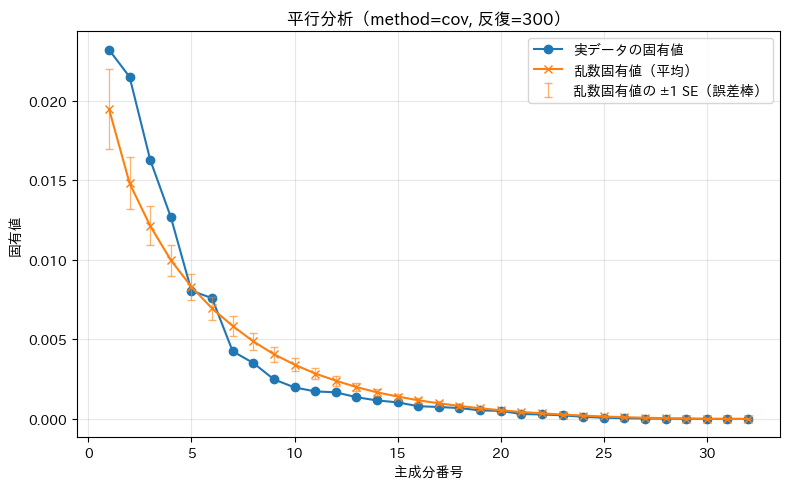

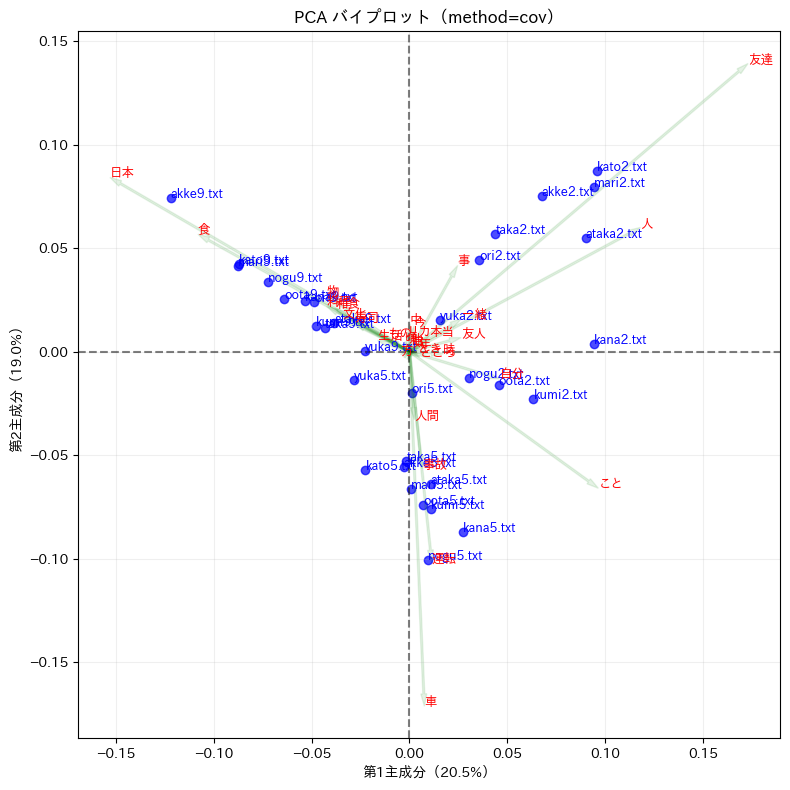

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.preprocessing import StandardScaler

# ============================================================
# データ準備
# df：度数データ（行=ファイル, 列=語）
# ============================================================
X = df.copy()

# --- 相対頻度 ---
X_rel = X.div(X.sum(axis=1), axis=0)

# OTHERS を除外
X_rel = X_rel.drop(columns=["OTHERS"], errors="ignore")

# --- 分散ゼロ列の除外 ---
col_std = X_rel.std(axis=0, ddof=0)
nonzero_cols = col_std > 0
X_rel = X_rel.loc[:, nonzero_cols]

# ============================================================
# 設定
# ============================================================
method = "cov"  #or "corr"
n_iter = 300   # ←推奨：200〜500
ci_type = "SE"  # "SE" または "95CI" を選択

# ============================================================
# ============================================================
# PCA（共分散 or 相関）
# ============================================================
def pca_eigs_and_scores(X_rel, method="cov"):
    if method == "corr":
        Z = StandardScaler().fit_transform(X_rel)
        mat = np.corrcoef(Z, rowvar=False)
        data_for_scores = Z
    elif method == "cov":
        Xc = X_rel - X_rel.mean(axis=0)
        mat = np.cov(Xc.T, bias=False)
        data_for_scores = Xc.to_numpy()
    else:
        raise ValueError("method must be 'corr' or 'cov'")

    w, v = np.linalg.eigh(mat)
    idx = np.argsort(w)[::-1]
    w = w[idx]
    v = v[:, idx]

    scores = data_for_scores @ v[:, :2]
    loadings = v[:, :2] * np.sqrt(w[:2])

    return np.asarray(scores), np.asarray(loadings), w

# ============================================================
# 平行分析（度数 perm → 相対頻度 → PCA）
# ============================================================
def parallel_analysis_from_counts(X_rel, method="corr", n_iter=100, seed=None):
    rng = np.random.default_rng(seed)
    m, n = X_rel.shape

    # 実データ固有値
    X_rel0 = X_rel.div(X_rel.sum(axis=1), axis=0)
    _, _, w_real = pca_eigs_and_scores(X_rel0, method=method)

    # 乱数固有値保存
    w_rand = np.zeros((n_iter, n))
    Xv = X_rel.to_numpy()

    for t in range(n_iter):
        R = np.empty_like(Xv)
        for j in range(n):
            R[:, j] = rng.permutation(Xv[:, j])

        row_sums = R.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        R_rel = R / row_sums

        # PCA 用の行列作成
        if method == "corr":
            Z = StandardScaler().fit_transform(R_rel)
            mat = np.corrcoef(Z, rowvar=False)
        else:
            Rc = R_rel - R_rel.mean(axis=0)
            mat = np.cov(Rc.T, bias=False)

        w, _ = np.linalg.eigh(mat)
        w_rand[t, :] = np.sort(w)[::-1]

    # 乱数固有値の統計量
    w_rand_mean = w_rand.mean(axis=0)

    return w_real, w_rand_mean, w_rand


# PCA（実データ）
# ============================================================
scores, loadings, w_real = pca_eigs_and_scores(X_rel, method=method)

# ============================================================
# 平行分析（ブートストラップデータ取得）
# ============================================================
w_real, w_rand_mean, w_rand = parallel_analysis_from_counts(
    X_rel, method=method, n_iter=n_iter, seed=0
)

# ============================================================
# ブートストラップ標準誤差（正しいエラーバー）
# ============================================================
SE_boot = w_rand.std(axis=0, ddof=1)

# CI 幅の切り替え
if ci_type == "SE":
    yerr = SE_boot
    ci_label = "±1 SE（誤差棒）"
elif ci_type == "95CI":
    yerr = 1.96 * SE_boot
    ci_label = "95%CI（1.96×SE）"
else:
    raise ValueError("ci_type must be 'SE' or '95CI'")

# ============================================================
# 平行分析プロット（エラーバー付き）
# ============================================================
k = np.arange(1, len(w_real) + 1)

plt.figure(figsize=(8, 5))
plt.plot(k, w_real, "-o", label="実データの固有値", zorder=3)

line_rand, = plt.plot(
    k, w_rand_mean, "-x",
    label="乱数固有値（平均）",
    zorder=3
)

plt.errorbar(
    k, w_rand_mean,
    yerr=yerr,
    fmt="none",
    ecolor=line_rand.get_color(),
    elinewidth=0.9,
    capsize=3,
    alpha=0.6,
    label=f"乱数固有値の {ci_label}",
    zorder=10
)

plt.xlabel("主成分番号")
plt.ylabel("固有値")
plt.title(f"平行分析（method={method}, 反復={n_iter}）")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Biplot（元の処理を維持）
# ============================================================
scale_factor = np.mean(np.std(scores, axis=0)) / (np.mean(np.std(loadings, axis=0)) + 1e-12)
loadings_scaled = loadings * scale_factor

contrib = w_real / w_real.sum() * 100
pc1_rate, pc2_rate = contrib[0], contrib[1]

plt.figure(figsize=(8, 8))

# スコア
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.7, c="blue")
for i, label in enumerate(X_rel.index):
    plt.text(scores[i, 0], scores[i, 1], str(label), c="blue", fontsize=9)

# 負荷量
for i, label in enumerate(X_rel.columns):
    x = loadings_scaled[i, 0]
    y = loadings_scaled[i, 1]
    plt.arrow(0, 0, x, y, color="green", alpha=0.1,
              head_width=0.003, head_length=0.006,
              length_includes_head=True)
    plt.text(x, y, str(label), c="red", fontsize=9)

plt.axhline(0, ls="--", c="black", alpha=0.5)
plt.axvline(0, ls="--", c="black", alpha=0.5)
plt.xlabel(f"第1主成分（{pc1_rate:.1f}%）")
plt.ylabel(f"第2主成分（{pc2_rate:.1f}%）")
plt.title(f"PCA バイプロット（method={method}）")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
### 対応分析

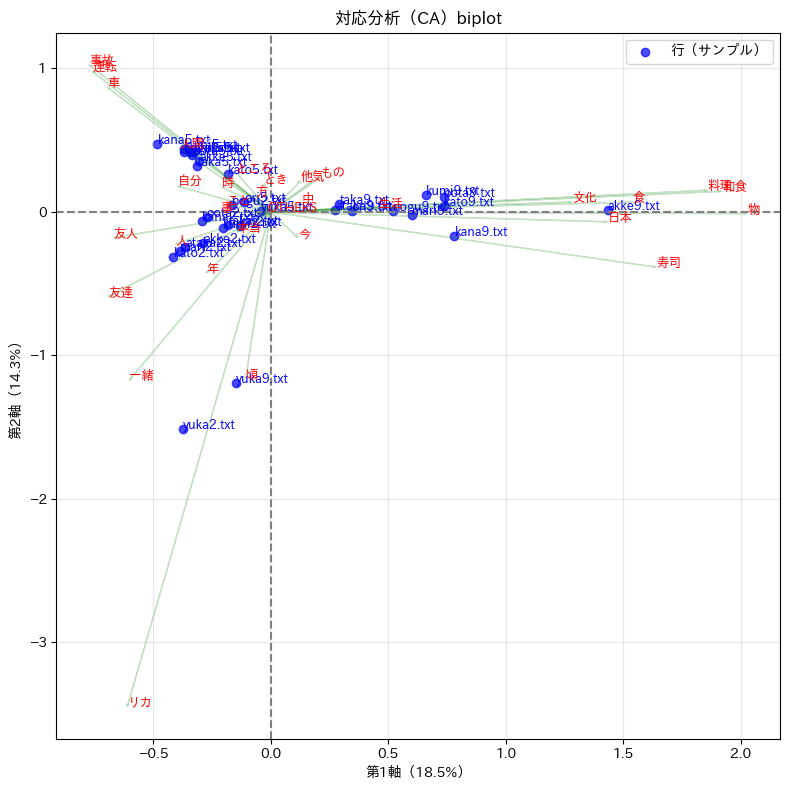

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# ============================================================
# df：度数表（行=サンプル、列=カテゴリ）
# ============================================================

# df = あなたの度数表データフレーム
X = df.copy()

# 行合計・列合計・総計
r = X.sum(axis=1).to_numpy()           # 行和
c = X.sum(axis=0).to_numpy()           # 列和
N = X.values.sum()                     # 総和

# 相対度数行列
P = X / N

# 行比率・列比率
r_hat = P.sum(axis=1).to_numpy()       # 行比率
c_hat = P.sum(axis=0).to_numpy()       # 列比率

# ============================================================
# 対応分析の中心行列（chi-square 残差の標準化）
# ============================================================
# R^(-1/2)
Dr_inv = np.diag(1 / np.sqrt(r_hat + 1e-12))

# C^(-1/2)
Dc_inv = np.diag(1 / np.sqrt(c_hat + 1e-12))

# 基本行列：標準化残差
S = Dr_inv @ (P - np.outer(r_hat, c_hat)) @ Dc_inv

# ============================================================
# SVD（特異値分解）
# ============================================================
U, singular_vals, Vt = np.linalg.svd(S, full_matrices=False)

# 特異値の2乗＝固有値
eigs = singular_vals**2

# ============================================================
# 行スコア・列スコア
# ============================================================

# 行座標
F = Dr_inv @ U[:, :2] @ np.diag(singular_vals[:2])

# 列座標
G = Dc_inv @ Vt.T[:, :2] @ np.diag(singular_vals[:2])

# ============================================================
# 寄与率（分散説明率）
# ============================================================
contrib = eigs / eigs.sum()
pc1_rate = contrib[0] * 100
pc2_rate = contrib[1] * 100

# ============================================================
# BIPLOT（行＝青，列＝赤）
# ============================================================
plt.figure(figsize=(8, 8))

# 行スコア
plt.scatter(F[:, 0], F[:, 1], c="blue", label="行（サンプル）", alpha=0.7)
for i, label in enumerate(X.index):
    plt.text(F[i, 0], F[i, 1], str(label), c="blue", fontsize=9)

# 列スコア（矢印）
for j, label in enumerate(X.columns):
    x, y = G[j, 0], G[j, 1]
    plt.arrow(0, 0, x, y, color="green", alpha=0.2,
              head_width=0.01, length_includes_head=True)
    plt.text(x, y, str(label), c="red", fontsize=9)

plt.axhline(0, ls="--", c="gray")
plt.axvline(0, ls="--", c="gray")
plt.xlabel(f"第1軸（{pc1_rate:.1f}%）")
plt.ylabel(f"第2軸（{pc2_rate:.1f}%）")
plt.title("対応分析（CA）biplot")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



===== W（サンプル×トピック）=====
            Topic1  Topic2  Topic3
akke2.txt    0.000   0.000   2.351
akke5.txt    0.584   0.000   0.000
akke9.txt    0.000   0.372   0.013
ataka2.txt   0.209   0.004   1.539
ataka5.txt   1.153   0.000   0.000
ataka9.txt   0.148   0.144   0.066
kana2.txt    0.660   0.024   0.782
kana5.txt    0.778   0.000   0.083
kana9.txt    0.000   0.110   0.091
kato2.txt    0.000   0.000   2.437
kato5.txt    0.538   0.000   0.000
kato9.txt    0.000   0.287   0.000
kumi2.txt    0.896   0.048   0.399
kumi5.txt    0.960   0.000   0.000
kumi9.txt    0.360   0.234   0.000
mari2.txt    0.000   0.000   1.801
mari5.txt    0.796   0.000   0.087
mari9.txt    0.000   0.398   0.000
nogu2.txt    0.880   0.036   0.504
nogu5.txt    1.108   0.000   0.000
nogu9.txt    0.102   0.374   0.000
oota2.txt    0.740   0.031   0.366
oota5.txt    0.784   0.000   0.000
oota9.txt    0.352   0.363   0.014
ori2.txt     0.112   0.056   1.101
ori5.txt     0.477   0.019   0.077
ori9.txt     0.024   0.147   0

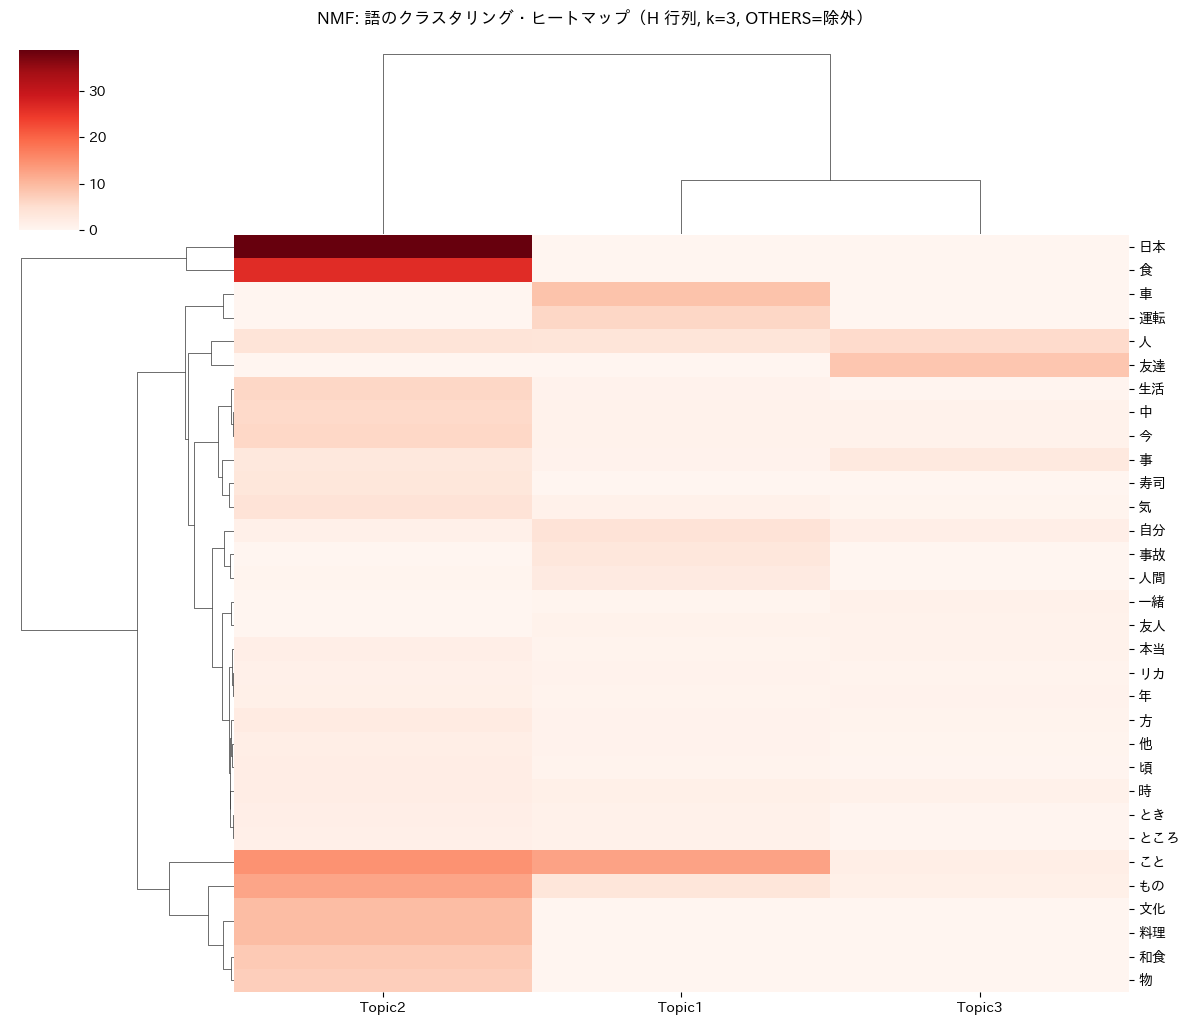

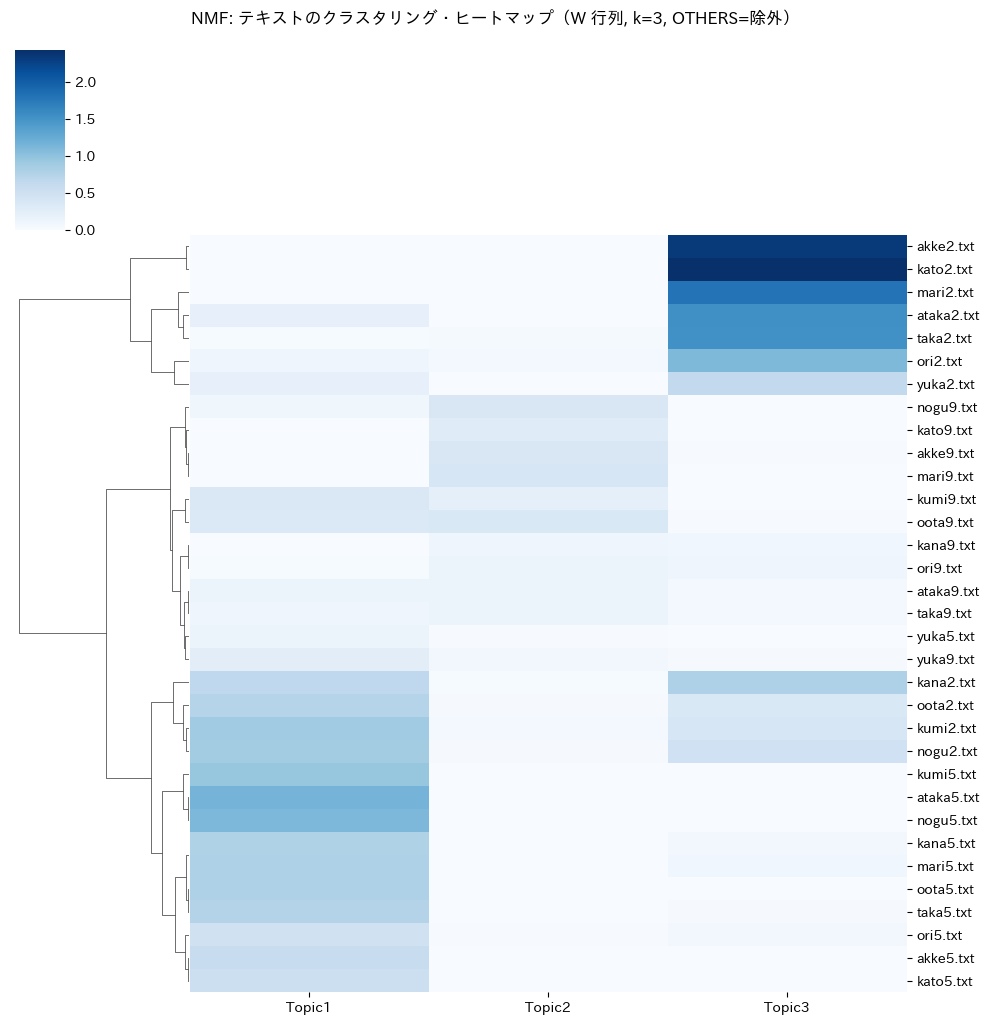

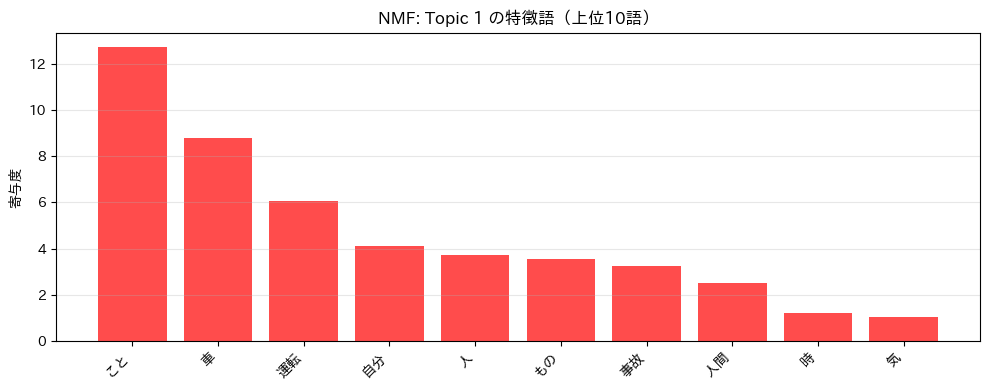

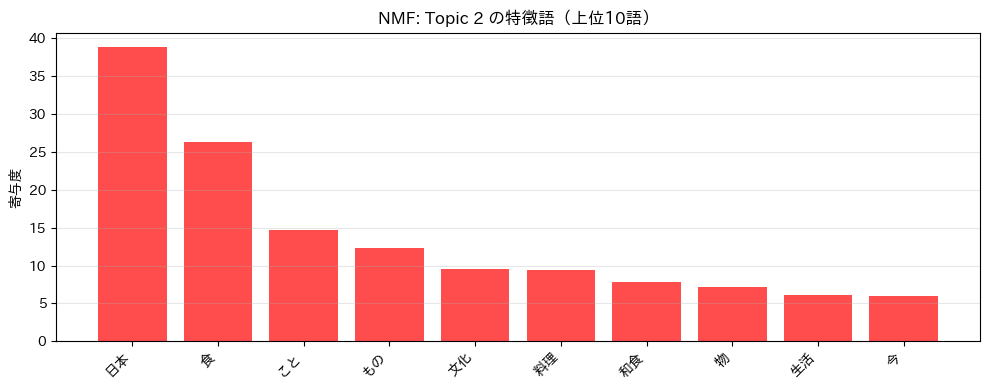

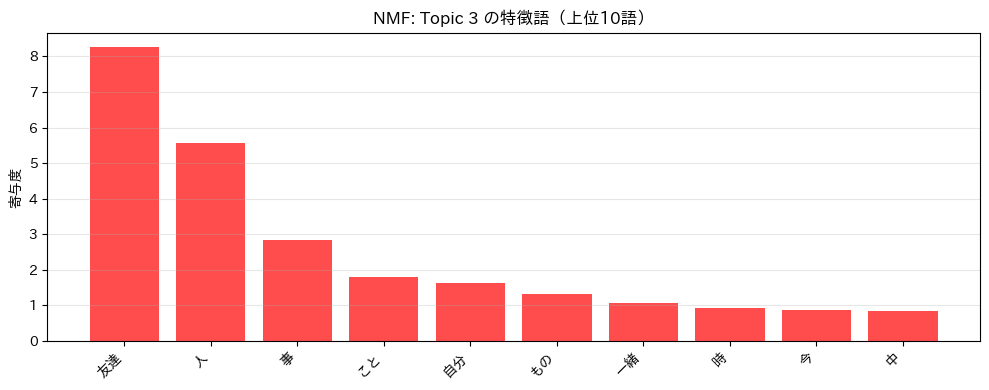

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.decomposition import NMF

# ============================================================
# 設定
# ============================================================
use_others = False     # True で OTHERS を使う / False で OTHERS を除外
k = 3  # NMF のトピック数（例：4）
linkage_method = "ward"   # 階層クラスタリングの手法

# ============================================================
# データ準備（df：度数データ）
# ============================================================
X = df.copy()

# OTHERS のオンオフ
if not use_others:
    X = X.drop(columns=["OTHERS"], errors="ignore")

# 非負行列にする（マイナス防止）
X = X.clip(lower=0)

# ============================================================
# NMF（非負行列因子分解）
# ============================================================
model = NMF(
    n_components=k,
    init="nndsvda",
    solver="cd",
    max_iter=500,
    random_state=0
)

W = model.fit_transform(X.values)    # shape = (n_samples, k)
H = model.components_                # shape = (k, n_terms)

# DataFrame で扱いやすく
W_df = pd.DataFrame(W, index=X.index, columns=[f"Topic{i+1}" for i in range(k)])
H_df = pd.DataFrame(H, index=[f"Topic{i+1}" for i in range(k)], columns=X.columns)

print("\n===== W（サンプル×トピック）=====")
print(W_df.round(3))
print("\n===== H（トピック×語）=====")
print(H_df.round(3))

# ============================================================
# 図示①：語 × トピック のクラスタリングヒートマップ（H 行列）
# ============================================================

sns.clustermap(
    H_df.T,               # 語 × トピック（行：語）
    method="ward",
    metric="euclidean",
    cmap="Reds",
    figsize=(12, 10),
    row_cluster=True,     # 語のクラスタリング
    col_cluster=True      # トピック側もクラスタリング（任意）
)

plt.suptitle(
    f"NMF: 語のクラスタリング・ヒートマップ（H 行列, k={k}, OTHERS={'使用' if use_others else '除外'}）",
    y=1.02
)
plt.show()

# ============================================================
# 図示②：サンプル × トピック のクラスタリングヒートマップ（W 行列）
# ============================================================

sns.clustermap(
    W_df,                 # サンプル × トピック
    method="ward",
    metric="euclidean",
    cmap="Blues",
    figsize=(10, 10),
    row_cluster=True,     # テキスト（行）のクラスタリング
    col_cluster=False     # トピック列はクラスタリングしない（意味維持）
)

plt.suptitle(
    f"NMF: テキストのクラスタリング・ヒートマップ（W 行列, k={k}, OTHERS={'使用' if use_others else '除外'}）",
    y=1.02
)
plt.show()

# ============================================================
# 図示③：各トピックの重要語（上位10語）
# ============================================================
for t in range(k):
    h_top = H_df.loc[f"Topic{t+1}"].sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 4))
    plt.bar(h_top.index, h_top.values, color="red", alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("寄与度")
    plt.title(f"NMF: Topic {t+1} の特徴語（上位10語）")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
### LDA_Topic Analysis


===== 語 × トピックの確率行列 =====
     Topic1  Topic2  Topic3
こと    0.177   0.115   0.099
とき    0.019   0.016   0.008
ところ   0.012   0.016   0.011
もの    0.058   0.062   0.064
リカ    0.001   0.001   0.066
一緒    0.033   0.001   0.001
中     0.025   0.016   0.027
事     0.052   0.039   0.021
事故    0.001   0.069   0.001
人     0.164   0.042   0.023
人間    0.012   0.041   0.014
今     0.031   0.011   0.033
他     0.010   0.015   0.011
友人    0.032   0.004   0.001
友達    0.178   0.001   0.001
和食    0.001   0.001   0.037
寿司    0.001   0.046   0.001
年     0.016   0.012   0.018
文化    0.001   0.001   0.044
料理    0.001   0.001   0.044
方     0.009   0.020   0.017
日本    0.001   0.001   0.181
時     0.028   0.022   0.011
本当    0.025   0.011   0.009
気     0.018   0.018   0.022
物     0.002   0.001   0.037
生活    0.011   0.014   0.035
自分    0.073   0.052   0.014
車     0.001   0.208   0.001
運転    0.001   0.134   0.001
頃     0.009   0.010   0.027
食     0.001   0.001   0.122


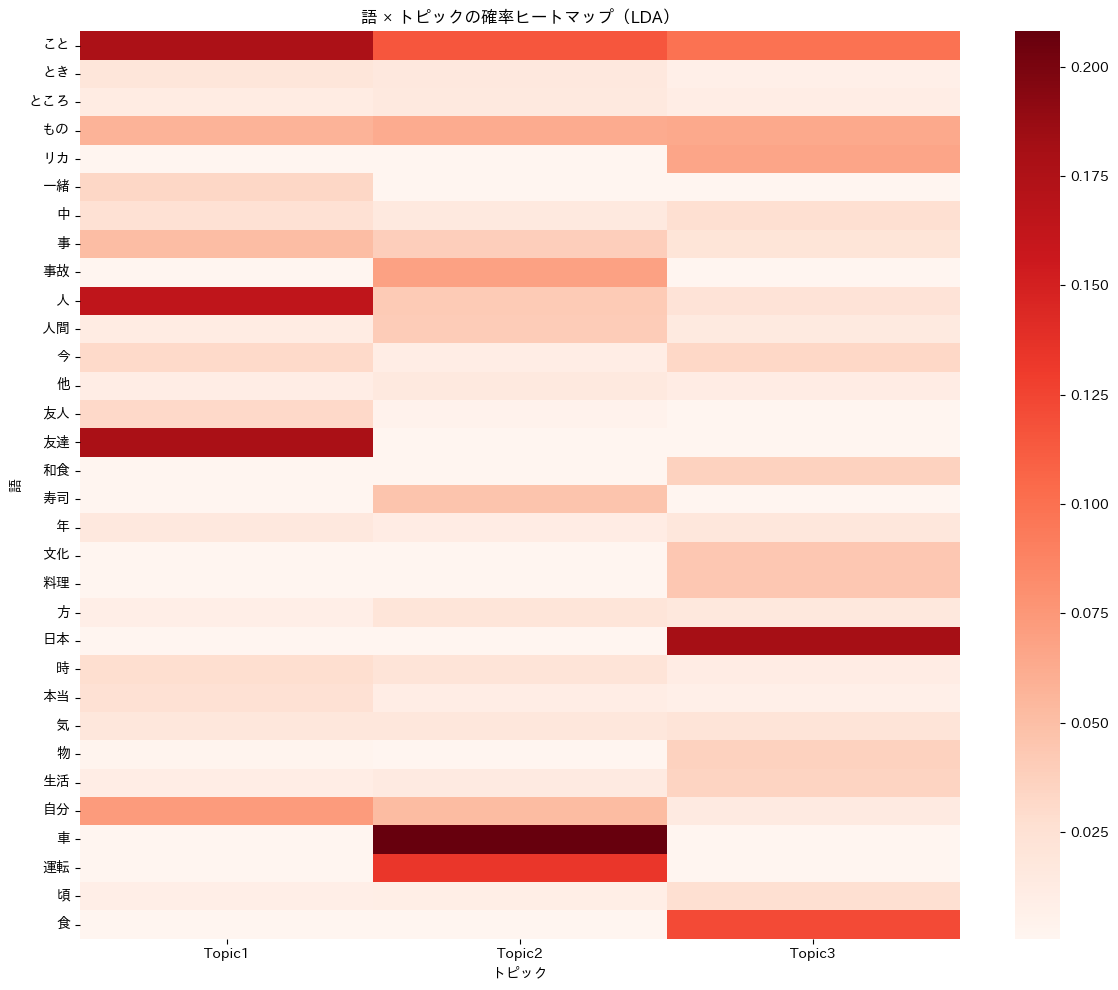

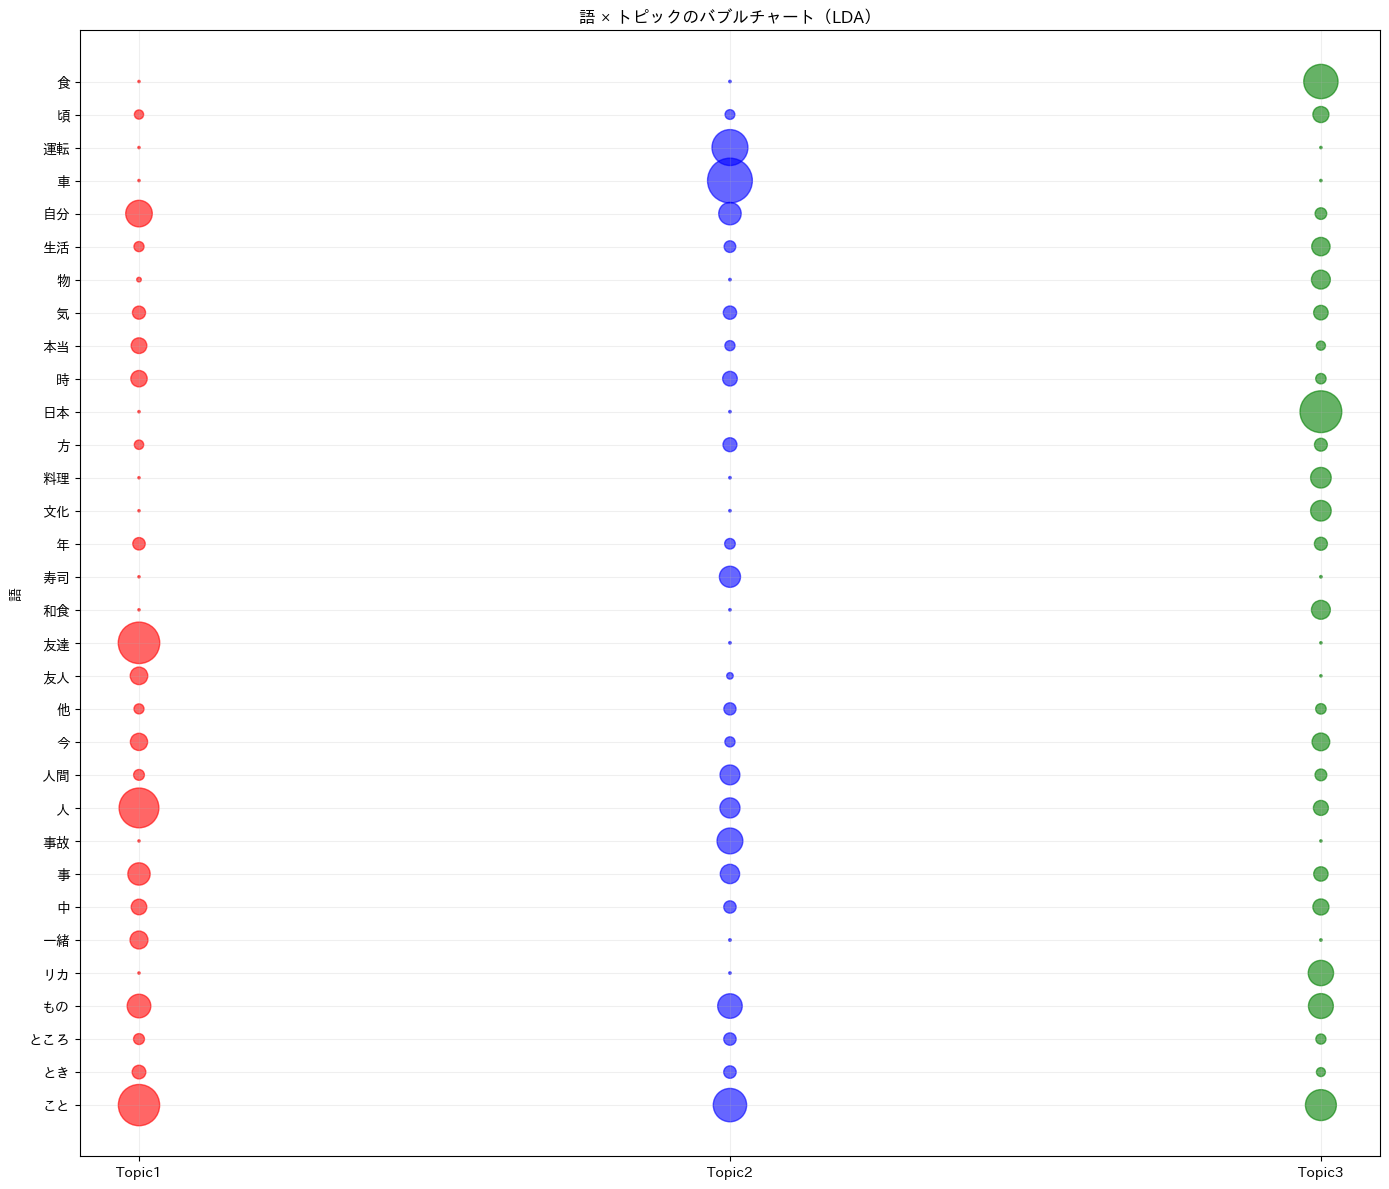

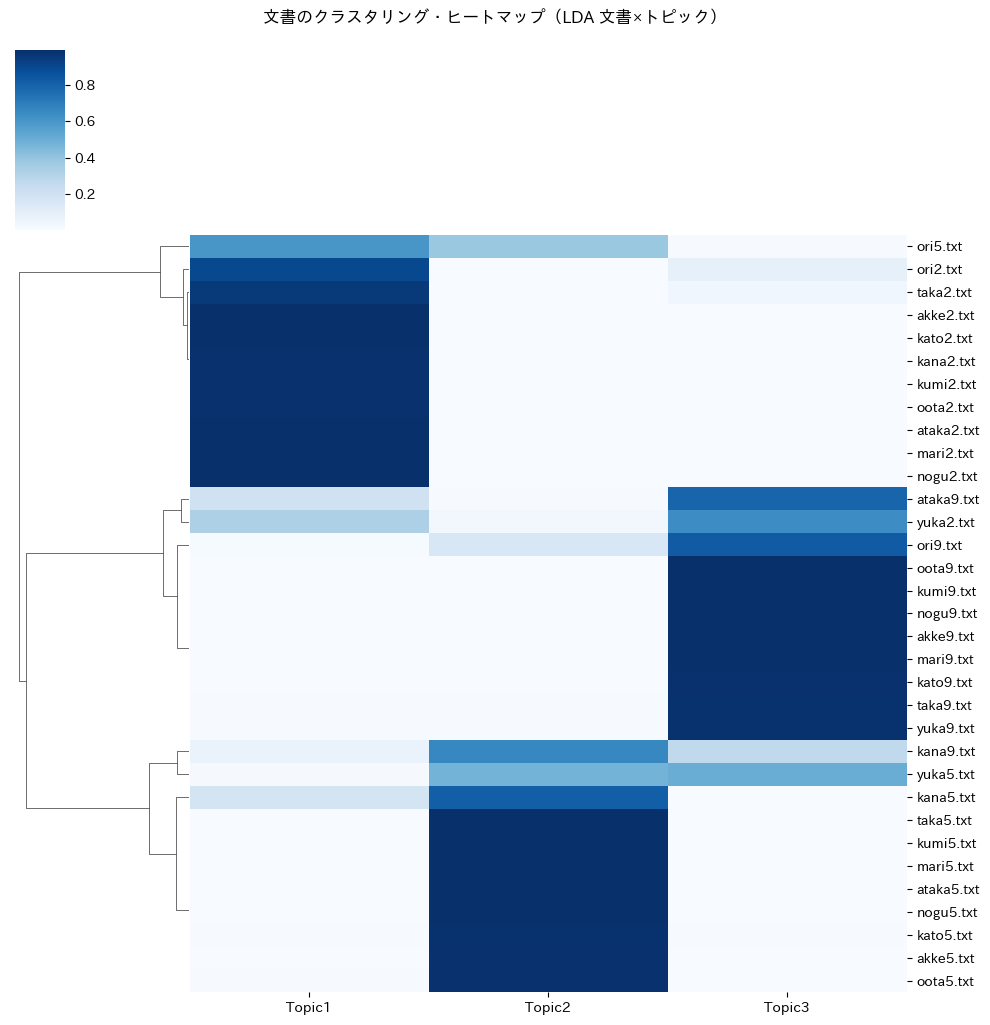

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation

# ============================================================
# 設定
# ============================================================
use_others = False
n_topics = 3      
random_state = 0

# ============================================================
# データ読み込み & 整形
# ============================================================
#path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
#d1 = pd.read_csv(path, encoding="shift-jis")

#doc_labels = d1.iloc[:, 0]                 # 文書ラベル
#X = d1.iloc[:, 1:]                      # 語データ（最後の列は文種）
#X.index = doc_labels

X = df.copy()
if not use_others:
    X = X.drop(columns=["OTHERS"], errors="ignore")

# ============================================================
# LDA 実行
# ============================================================
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=random_state,
    learning_method='batch'
)

lda.fit(X.values)

# 文書×トピック確率
doc_topic = lda.transform(X.values)
doc_topic_df = pd.DataFrame(doc_topic, index=X.index,
                            columns=[f"Topic{i+1}" for i in range(n_topics)])

# 語×トピック確率（語 × Topic に転置）
topic_word = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]
topic_word_df = pd.DataFrame(topic_word.T, 
                             index=X.columns,
                             columns=[f"Topic{i+1}" for i in range(n_topics)])

print("\n===== 語 × トピックの確率行列 =====")
print(topic_word_df.round(3))

# ============================================================
# ① 語 × トピックのヒートマップ
# ============================================================

plt.figure(figsize=(12, 10))
sns.heatmap(topic_word_df, cmap="Reds")
plt.title("語 × トピックの確率ヒートマップ（LDA）")
plt.xlabel("トピック")
plt.ylabel("語")
plt.tight_layout()
plt.show()

# ============================================================
# ② 語 × トピックのバブルチャート（トピックごとに色分け）
# ============================================================

# トピックごとの鮮やかな色(15種類)
topic_colors = [
    "red", "blue", "green", "orange", "purple",
    "cyan", "magenta", "gold", "lime", "pink",
    "teal", "brown", "navy", "olive", "darkred"
]

bubble_df = topic_word_df.reset_index().melt(
    id_vars="index",
    var_name="Topic",
    value_name="Prob"
)
bubble_df.columns = ["Word", "Topic", "Prob"]

plt.figure(figsize=(14, 12))

for i, topic in enumerate(topic_word_df.columns):
    sub = bubble_df[bubble_df["Topic"] == topic]
    plt.scatter(
        x=[topic]*len(sub),
        y=sub["Word"],
        s=sub["Prob"] * 5000,     # バブルサイズ
        alpha=0.6,
        color=topic_colors[i]
    )

plt.ylabel("語")
plt.title("語 × トピックのバブルチャート（LDA）")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# ③ 文書 × トピックのクラスタリングヒートマップ（削除しない）
# ============================================================

g = sns.clustermap(
    doc_topic_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    figsize=(10, 10),
    row_cluster=True,
    col_cluster=False
)

# 行ラベルを横書きにする
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

plt.suptitle("文書のクラスタリング・ヒートマップ（LDA 文書×トピック）", y=1.02)
plt.show()
